# Feature Engineering – Outliers

# Import Libraries

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Create sample dataset

In [20]:
np.random.seed(42)
data = np.random.normal(50, 10, 100)  # Normal distribution
data = np.append(data, [150, 200, 250])  # Adding outliers

df = pd.DataFrame(data, columns=["Value"])

# 1. Detect Outliers using IQR

In [21]:
Q1 = df["Value"].quantile(0.25)
Q3 = df["Value"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["Value"] < lower_bound) | (df["Value"] > upper_bound)]

# 2. Detect Outliers using Z-Score

In [22]:
df["z_score"] = (df["Value"] - df["Value"].mean()) / df["Value"].std()
outliers_z = df[df["z_score"].abs() > 3]

# 3. Detect Outliers using Isolation Forest

In [23]:
iso = IsolationForest(contamination=0.05)
df["anomaly"] = iso.fit_predict(df[["Value"]])
outliers_if = df[df["anomaly"] == -1]

print("IQR Outliers:\n", outliers_iqr)
print("\nZ-Score Outliers:\n", outliers_z)
print("\nIsolation Forest Outliers:\n", outliers_if)

IQR Outliers:
           Value
74    23.802549
100  150.000000
101  200.000000
102  250.000000

Z-Score Outliers:
      Value   z_score
100  150.0  3.459160
101  200.0  5.248888
102  250.0  7.038616

Isolation Forest Outliers:
           Value   z_score  anomaly
31    68.522782  0.542720       -1
74    23.802549 -1.058021       -1
79    30.124311 -0.831737       -1
100  150.000000  3.459160       -1
101  200.000000  5.248888       -1
102  250.000000  7.038616       -1


# Plot the dataset with outliers

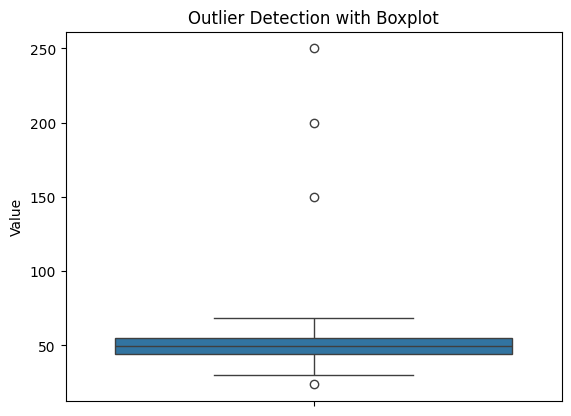

In [18]:
sns.boxplot(df["Value"])
plt.title("Outlier Detection with Boxplot")
plt.show()